
# Transformer-Based Sentiment and Emotion Analysis (contextual)

This notebook extends the lexicon-based analysis by applying a contextual transformer model to the English-language lyrics sample.

The objective is to examine whether transformer-based emotion classification reveals similar temporal and music-cluster patterns to those identified with NRC EmoLex.

Unlike the word-level lexicon approach, transformer models incorporate the surrounding linguistic context when estimating emotion. Because song lyrics frequently exceed the model input limit, lyrics will be divided into token-based chunks, classified separately, and aggregated into track-level emotion profiles.

## 1. Load the NRC analysis dataset

environment: `music-transformer`

In [1]:
import pandas as pd
import numpy as np

lyrics_df = pd.read_csv(
    "../data/processed/final/lyrics_nrc_analysis.csv"
)

lyrics_df.shape

(523, 43)

In [2]:
lyrics_df[
    [
        "artist",
        "track",
        "era",
        "macro_cluster",
        "lyrics_clean",
        "lexicon_coverage"
    ]
].head()

,artist,track,era,macro_cluster,lyrics_clean,lexicon_coverage
0,Angels & Airwaves,Secret Crowds,2008-2011,Alternative Core,If I had my own world...\nI'd build you an emp...,0.144772
1,Red Hot Chili Peppers,Monarchy of Roses,2008-2011,Alternative Core,The crimson tide is flowing through your finge...,0.077778
2,Brandon Flowers,Only the Young,2008-2011,Alternative Core,Look back in silence\nThe cradle of your whole...,0.165414
3,Pennywise,Living for Today,2008-2011,Alternative Core,"One, two, three, four\n\nYou look around\nWhat...",0.100000
4,Katie Melua,The Closest Thing to Crazy,2008-2011,Alternative Core,How can I think I'm standing strong\nYet feel ...,0.116883


## 2. Select and load the transformer model

For the contextual emotion analysis, the `j-hartmann/emotion-english-distilroberta-base` model is used.

The model predicts seven emotion classes:

- anger
- disgust
- fear
- joy
- neutral
- sadness
- surprise

Six of these categories directly overlap with NRC EmoLex (`anger`, `disgust`, `fear`, `joy`, `sadness`, and `surprise`), enabling a later comparison between lexicon-based and transformer-based emotion profiles.

The transformer additionally includes a `neutral` class, while NRC-specific `anticipation` and `trust` categories do not have direct equivalents in this model.

In [3]:
import numpy as np
import torch
import transformers

print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)

NumPy: 1.26.4
PyTorch: 2.2.2
Transformers: 4.44.2


In [4]:
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print("Device:", device)

Device: cpu


In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "j-hartmann/emotion-english-distilroberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME
)

model.to("cpu")
model.eval()

/usr/local/anaconda3/envs/music-transformer/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (

In [5]:
print("Maximum input length:", tokenizer.model_max_length)
print("Number of labels:", model.config.num_labels)
print("Labels:", model.config.id2label)

Maximum input length: 512
Number of labels: 7
Labels: {0: 'anger', 1: 'disgust', 2: 'fear', 3: 'joy', 4: 'neutral', 5: 'sadness', 6: 'surprise'}


In [6]:
def count_transformer_tokens(text):
    return len(
        tokenizer.encode(
            text,
            add_special_tokens=False,
            truncation=False
        )
    )


lyrics_df["transformer_tokens"] = (
    lyrics_df["lyrics_clean"]
    .apply(count_transformer_tokens)
)

lyrics_df["transformer_tokens"].describe()

Token indices sequence length is longer than the specified maximum sequence length for this model (536 > 512). Running this sequence through the model will result in indexing errors


count     523.000000
mean      285.325048
std       150.041544
min        12.000000
25%       186.500000
50%       260.000000
75%       360.500000
max      1294.000000
Name: transformer_tokens, dtype: float64

In [7]:
print(
    "Tracks above 510 tokens:",
    (lyrics_df["transformer_tokens"] > 510).sum()
)

print(
    "Share above 510 tokens:",
    round(
        (lyrics_df["transformer_tokens"] > 510).mean() * 100,
        1
    ),
    "%"
)

Tracks above 510 tokens: 36
Share above 510 tokens: 6.9 %


## 3. Prepare token-based lyrics chunks

The transformer accepts a maximum sequence length of 512 tokens. Most lyrics in the dataset fit within this limit, but 36 of 523 tracks (6.9%) exceed it.

To preserve the complete lyrics rather than truncate longer tracks, each text is divided into token-based chunks. Tracks below the model limit produce a single chunk, while longer tracks produce multiple chunks.

A maximum of 510 content tokens per chunk is used, leaving space for the special tokens added by the RoBERTa tokenizer.

In [9]:
MAX_CONTENT_TOKENS = 510

def chunk_lyrics(text):
    tokens_ids = tokenizer.encode(
        text,
        add_special_tokens=False,
        truncation=False
    )
    
    chunks = []
    
    for start in range(0, len(tokens_ids), MAX_CONTENT_TOKENS):
        end = start + MAX_CONTENT_TOKENS
        chunk_ids = tokens_ids[start:end]
       
        chunk_text = tokenizer.decode(
            chunk_ids,
            skip_special_tokens=True
        )
        chunks.append(chunk_text)
        
    return chunks

In [11]:
lyrics_df["lyrics_chunks"] = (lyrics_df["lyrics_clean"].apply(chunk_lyrics))

lyrics_df["n_chunks"] = lyrics_df["lyrics_chunks"].apply(len)

In [12]:
lyrics_df["n_chunks"].value_counts().sort_index()

n_chunks
1    487
2     35
3      1
Name: count, dtype: int64

In [13]:
lyrics_df["n_chunks"].describe()

count    523.000000
mean       1.070746
std        0.264004
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: n_chunks, dtype: float64

## 4. Validate the inference pipeline

Before applying the transformer to the complete lyrics corpus, the inference process is tested on individual lyrics chunks.

For each chunk, the tokenizer converts the text into model input tokens. The transformer produces one logit for each of its seven emotion classes. A softmax transformation converts these logits into a probability distribution whose values sum to 1.

In [14]:
sample_row = lyrics_df.iloc[0]

print("Artist:", sample_row["artist"])
print("Track:", sample_row["track"])
print("Chunks:", sample_row["n_chunks"])

Artist: Angels & Airwaves
Track: Secret Crowds
Chunks: 1


In [15]:
sample_chunk = sample_row["lyrics_chunks"][0]

inputs = tokenizer(
    sample_chunk,
    return_tensors="pt",
    truncation=True,
    max_length=512
)

inputs["input_ids"].shape

torch.Size([1, 467])

In [16]:
with torch.no_grad():
    outputs = model(**inputs)

outputs.logits

tensor([[ 1.6699, -1.1493,  0.6340,  1.4326,  0.8971, -0.9459, -1.4881]])

In [17]:
probabilities = torch.softmax(
    outputs.logits,
    dim=1
)[0]

probabilities

tensor([0.3596, 0.0215, 0.1276, 0.2836, 0.1661, 0.0263, 0.0153])

In [18]:
emotion_probabilities = {
    model.config.id2label[i]: probabilities[i].item()
    for i in range(model.config.num_labels)
}

emotion_probabilities

{'anger': 0.35963916778564453,
 'disgust': 0.02145352214574814,
 'fear': 0.12762929499149323,
 'joy': 0.2836442291736603,
 'neutral': 0.16605223715305328,
 'sadness': 0.026292899623513222,
 'surprise': 0.015288621187210083}

In [19]:
sum(emotion_probabilities.values())

0.9999999720603228

In [20]:
def predict_chunk_emotions(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=1
    )[0]

    return {
        model.config.id2label[i]: probabilities[i].item()
        for i in range(model.config.num_labels)
    }

In [21]:
predict_chunk_emotions(sample_chunk)

{'anger': 0.35963916778564453,
 'disgust': 0.02145352214574814,
 'fear': 0.12762929499149323,
 'joy': 0.2836442291736603,
 'neutral': 0.16605223715305328,
 'sadness': 0.026292899623513222,
 'surprise': 0.015288621187210083}

In [22]:
multi_chunk_sample = lyrics_df[
    lyrics_df["n_chunks"] > 1
].iloc[0]

print("Artist:", multi_chunk_sample["artist"])
print("Track:", multi_chunk_sample["track"])
print("Tokens:", multi_chunk_sample["transformer_tokens"])
print("Chunks:", multi_chunk_sample["n_chunks"])

Artist: Pennywise
Track: Living for Today
Tokens: 536
Chunks: 2


In [23]:
for i, chunk in enumerate(multi_chunk_sample["lyrics_chunks"], start=1):
    print(f"\nChunk {i}")
    print(predict_chunk_emotions(chunk))


Chunk 1
{'anger': 0.21138174831867218, 'disgust': 0.03348756581544876, 'fear': 0.3811492621898651, 'joy': 0.019874805584549904, 'neutral': 0.2015458047389984, 'sadness': 0.12255361676216125, 'surprise': 0.030007269233465195}

Chunk 2
{'anger': 0.006963303778320551, 'disgust': 0.005126379895955324, 'fear': 0.007376148831099272, 'joy': 0.03344574198126793, 'neutral': 0.5197161436080933, 'sadness': 0.02374756522476673, 'surprise': 0.4036247432231903}


### 4.1 Track-level aggregation
For tracks requiring multiple chunks, chunk-level probability distributions were aggregated using the number of content tokens in each chunk as weights. This prevents short final chunks from contributing equally to the track-level profile as substantially longer chunks.

In [24]:
def predict_track_emotions(chunks):
    chunk_results = []

    for chunk in chunks:
        probabilities = predict_chunk_emotions(chunk)

        n_tokens = len(
            tokenizer.encode(
                chunk,
                add_special_tokens=False,
                truncation=False
            )
        )

        chunk_results.append({
            "probabilities": probabilities,
            "n_tokens": n_tokens
        })

    return chunk_results

In [25]:
chunk_results = predict_track_emotions(
    multi_chunk_sample["lyrics_chunks"]
)

chunk_results

[{'probabilities': {'anger': 0.21138174831867218,
   'disgust': 0.03348756581544876,
   'fear': 0.3811492621898651,
   'joy': 0.019874805584549904,
   'neutral': 0.2015458047389984,
   'sadness': 0.12255361676216125,
   'surprise': 0.030007269233465195},
  'n_tokens': 510},
 {'probabilities': {'anger': 0.006963303778320551,
   'disgust': 0.005126379895955324,
   'fear': 0.007376148831099272,
   'joy': 0.03344574198126793,
   'neutral': 0.5197161436080933,
   'sadness': 0.02374756522476673,
   'surprise': 0.4036247432231903},
  'n_tokens': 26}]

In [26]:
def aggregate_track_emotions(chunk_results):
    labels = model.config.id2label.values()

    total_tokens = sum(
        result["n_tokens"]
        for result in chunk_results
    )

    track_profile = {}

    for label in labels:
        weighted_sum = sum(
            result["probabilities"][label] * result["n_tokens"]
            for result in chunk_results
        )

        track_profile[label] = weighted_sum / total_tokens

    return track_profile

In [27]:
pennywise_profile = aggregate_track_emotions(chunk_results)

pennywise_profile

{'anger': 0.20146592824768497,
 'disgust': 0.03211183664771214,
 'fear': 0.36301847684037275,
 'joy': 0.02053309727543548,
 'neutral': 0.21697944057966345,
 'sadness': 0.11776078590400406,
 'surprise': 0.04813050491207126}

In [28]:
sum(pennywise_profile.values())

1.000000070406944

## 5. Run transformer inference

The validated inference pipeline is applied to all 523 English-language tracks.

Each lyrics chunk is classified independently. For tracks consisting of multiple chunks, the resulting probability distributions are aggregated using chunk token counts as weights, producing one seven-dimensional emotion profile per track.

In [29]:
def predict_full_track(chunks):
    chunk_results = predict_track_emotions(chunks)
    return aggregate_track_emotions(chunk_results)

In [30]:
predict_full_track(
    multi_chunk_sample["lyrics_chunks"]
)

{'anger': 0.20146592824768497,
 'disgust': 0.03211183664771214,
 'fear': 0.36301847684037275,
 'joy': 0.02053309727543548,
 'neutral': 0.21697944057966345,
 'sadness': 0.11776078590400406,
 'surprise': 0.04813050491207126}

In [31]:
from tqdm.auto import tqdm

tqdm.pandas()

In [32]:
lyrics_df["transformer_emotions"] = lyrics_df["lyrics_chunks"].progress_apply(predict_full_track)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  0%|          | 0/523 [00:00<?, ?it/s]

In [33]:
lyrics_df[
    [
        "artist",
        "track",
        "n_chunks",
        "transformer_emotions"
    ]
].head()

,artist,track,n_chunks,transformer_emotions
0,Angels & Airwaves,Secret Crowds,1,"{'anger': 0.35963916778564453, 'disgust': 0.02..."
1,Red Hot Chili Peppers,Monarchy of Roses,1,"{'anger': 0.19674250483512878, 'disgust': 0.04..."
2,Brandon Flowers,Only the Young,1,"{'anger': 0.04605564475059509, 'disgust': 0.01..."
3,Pennywise,Living for Today,2,"{'anger': 0.20146592824768497, 'disgust': 0.03..."
4,Katie Melua,The Closest Thing to Crazy,1,"{'anger': 0.03131033480167389, 'disgust': 0.00..."


In [34]:
lyrics_df["transformer_emotions"].apply(
    lambda x: sum(x.values())
).describe()

count    5.230000e+02
mean     1.000000e+00
std      5.691183e-08
min      9.999998e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: transformer_emotions, dtype: float64

## 6. Build track-level emotion profiles

In [35]:
transformer_profiles = pd.json_normalize(lyrics_df["transformer_emotions"])

transformer_profiles = transformer_profiles.add_prefix("transformer_")

transformer_profiles.head()

,transformer_anger,transformer_disgust,transformer_fear,transformer_joy,transformer_neutral,transformer_sadness,transformer_surprise
0,0.359639,0.021454,0.127629,0.283644,0.166052,0.026293,0.015289
1,0.196743,0.046606,0.040945,0.023721,0.650218,0.020460,0.021308
2,0.046056,0.014156,0.098083,0.033520,0.186243,0.613036,0.008907
3,0.201466,0.032112,0.363018,0.020533,0.216979,0.117761,0.048131
4,0.031310,0.006559,0.034508,0.002833,0.011455,0.892777,0.020558


In [36]:
lyrics_df = pd.concat(
    [
        lyrics_df.reset_index(drop=True),
        transformer_profiles.reset_index(drop=True)
    ],
    axis=1
)

In [37]:
transformer_columns = [
    "transformer_anger",
    "transformer_disgust",
    "transformer_fear",
    "transformer_joy",
    "transformer_neutral",
    "transformer_sadness",
    "transformer_surprise"
]

lyrics_df[transformer_columns].describe()

,transformer_anger,transformer_disgust,transformer_fear,transformer_joy,transformer_neutral,transformer_sadness,transformer_surprise
count,523.000000,523.000000,523.000000,523.000000,523.000000,523.000000,523.000000
mean,0.139066,0.070105,0.293207,0.037293,0.157345,0.243151,0.059833
std,0.189854,0.116235,0.317132,0.119785,0.178475,0.295968,0.113636
min,0.000949,0.000420,0.001235,0.000504,0.000907,0.001707,0.000643
25%,0.016593,0.008985,0.045320,0.003866,0.033469,0.028920,0.008384
50%,0.055037,0.028132,0.148760,0.007278,0.086209,0.091524,0.021483
75%,0.164085,0.073093,0.446332,0.018175,0.214295,0.370302,0.058312
max,0.980059,0.831920,0.992156,0.896919,0.864527,0.981385,0.834113


In [38]:
lyrics_df[transformer_columns].sum(axis=1).describe()

count    5.230000e+02
mean     1.000000e+00
std      5.691183e-08
min      9.999998e-01
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

In [39]:
# Adding dominat emotion column based on the highest probability from the transformer model

lyrics_df["transformer_dominant_emotion"] = (lyrics_df[transformer_columns].idxmax(axis=1).str.replace("transformer_", "", regex=False))

In [40]:
lyrics_df["transformer_dominant_emotion"].value_counts()

transformer_dominant_emotion
fear        171
sadness     141
anger        80
neutral      79
disgust      23
surprise     15
joy          14
Name: count, dtype: int64

In [41]:
lyrics_df.to_pickle(
    "../data/processed/final/lyrics_transformer_analysis.pkl"
)

In [42]:
lyrics_df[transformer_columns].describe()

,transformer_anger,transformer_disgust,transformer_fear,transformer_joy,transformer_neutral,transformer_sadness,transformer_surprise
count,523.000000,523.000000,523.000000,523.000000,523.000000,523.000000,523.000000
mean,0.139066,0.070105,0.293207,0.037293,0.157345,0.243151,0.059833
std,0.189854,0.116235,0.317132,0.119785,0.178475,0.295968,0.113636
min,0.000949,0.000420,0.001235,0.000504,0.000907,0.001707,0.000643
25%,0.016593,0.008985,0.045320,0.003866,0.033469,0.028920,0.008384
50%,0.055037,0.028132,0.148760,0.007278,0.086209,0.091524,0.021483
75%,0.164085,0.073093,0.446332,0.018175,0.214295,0.370302,0.058312
max,0.980059,0.831920,0.992156,0.896919,0.864527,0.981385,0.834113


In [43]:
mean_transformer_profile = (lyrics_df[transformer_columns].mean().sort_values(ascending=False))

mean_transformer_profile

transformer_fear        0.293207
transformer_sadness     0.243151
transformer_neutral     0.157345
transformer_anger       0.139066
transformer_disgust     0.070105
transformer_surprise    0.059833
transformer_joy         0.037293
dtype: float64

Joy interesting: mean is only 3.7%, median 0.7%, but maximum 89.7% - so model confident of joy but only in a small part of the corpus

## 7. Emotion profiles across eras and music clusters

In [44]:
transformer_by_era = (
    lyrics_df
    .groupby("era")[transformer_columns]
    .mean()
)

transformer_by_era

,transformer_anger,transformer_disgust,transformer_fear,transformer_joy,transformer_neutral,transformer_sadness,transformer_surprise
era,,,,,,,
2008-2011,0.137915,0.063938,0.294410,0.044975,0.150265,0.226084,0.082413
2012-2016,0.148110,0.063530,0.299504,0.028565,0.136689,0.280157,0.043444
2017-2021,0.127581,0.060952,0.279866,0.040045,0.182331,0.250192,0.059033
2022-2025,0.143487,0.095497,0.300308,0.035384,0.159756,0.211549,0.054019


In [45]:
transformer_by_era.sum(axis=1)

era
2008-2011    1.0
2012-2016    1.0
2017-2021    1.0
2022-2025    1.0
dtype: float64

In [48]:
transformer_by_macro = (lyrics_df.groupby("macro_cluster")[transformer_columns].mean())

transformer_by_macro

,transformer_anger,transformer_disgust,transformer_fear,transformer_joy,transformer_neutral,transformer_sadness,transformer_surprise
macro_cluster,,,,,,,
Alternative Core,0.141494,0.059810,0.264566,0.048078,0.197226,0.225293,0.063533
Electronic & Ambient,0.127810,0.078931,0.288401,0.019218,0.131070,0.303282,0.051288
Rock & Britrock,0.167100,0.086607,0.301246,0.037073,0.141461,0.205621,0.060893
Singer-Songwriter,0.106632,0.035770,0.322588,0.059084,0.187897,0.218308,0.069721


In [50]:
transformer_by_macro.sum(axis=1)

macro_cluster
Alternative Core        1.0
Electronic & Ambient    1.0
Rock & Britrock         1.0
Singer-Songwriter       1.0
dtype: float64

In [51]:
transformer_by_era_macro = (lyrics_df.groupby(["era", "macro_cluster"])[transformer_columns].mean())

transformer_by_era_macro

transformer_anger  transformer_disgust  \
era       macro_cluster                                                  
2008-2011 Alternative Core               0.130725             0.045521   
          Electronic & Ambient           0.145097             0.069323   
          Rock & Britrock                0.168221             0.094840   
          Singer-Songwriter              0.091358             0.028248   
2012-2016 Alternative Core               0.156595             0.074115   
          Electronic & Ambient           0.153374             0.063264   
          Rock & Britrock                0.164649             0.074784   
          Singer-Songwriter              0.086725             0.023733   
2017-2021 Alternative Core               0.093297             0.043798   
          Electronic & Ambient           0.086494             0.075070   
          Rock & Britrock                0.180191             0.064830   
          Singer-Songwriter              0.145887             0.050356   
2022-2025 Alternative Core               0.186497             0.074286   
          Electronic & Ambient           0.125010             0.109602   
          Rock & Britrock                0.153339             0.116101   
          Singer-Songwriter              0.092388             0.040598   

                                transformer_fear  transformer_joy  \
era       macro_cluster                                             
2008-2011 Alternative Core              0.279927         0.044531   
          Electronic & Ambient          0.297613         0.013575   
          Rock & Britrock               0.337524         0.050340   
          Singer-Songwriter             0.241136         0.079986   
2012-2016 Alternative Core              0.198139         0.085344   
          Electronic & Ambient          0.287404         0.016931   
          Rock & Britrock               0.315142         0.010697   
          Singer-Songwriter             0.449764         0.008628   
2017-2021 Alternative Core              0.293820         0.017434   
          Electronic & Ambient          0.260934         0.030431   
          Rock & Britrock               0.273723         0.056312   
          Singer-Songwriter             0.305343         0.053647   
2022-2025 Alternative Core              0.292976         0.042787   
          Electronic & Ambient          0.308895         0.015666   
          Rock & Britrock               0.276211         0.029557   
          Singer-Songwriter             0.350742         0.094362   

                                transformer_neutral  transformer_sadness  \
era       macro_cluster                                                    
2008-2011 Alternative Core                 0.201689             0.216681   
          Electronic & Ambient             0.139296             0.256651   
          Rock & Britrock                  0.100868             0.170055   
          Singer-Songwriter                0.192296             0.271970   
2012-2016 Alternative Core                 0.187807             0.246718   
          Electronic & Ambient             0.125394             0.318115   
          Rock & Britrock                  0.114961             0.272238   
          Singer-Songwriter                0.132903             0.256388   
2017-2021 Alternative Core                 0.210513             0.273260   
          Electronic & Ambient             0.135454             0.359627   
          Rock & Britrock                  0.191232             0.183338   
          Singer-Songwriter                0.213329             0.156565   
2022-2025 Alternative Core                 0.189305             0.157687   
          Electronic & Ambient             0.125121             0.273277   
          Rock & Britrock                  0.159806             0.196253   
          Singer-Songwriter                0.206184             0.170135   

                                transformer_surprise  
era       macro_cluster         

In [52]:
era_macro_counts = (
    lyrics_df
    .groupby(["era", "macro_cluster"])
    .size()
    .unstack()
)

era_macro_counts

macro_cluster,Alternative Core,Electronic & Ambient,Rock & Britrock,Singer-Songwriter
era,,,,
2008-2011,24,39,41,29
2012-2016,29,46,41,19
2017-2021,28,42,42,26
2022-2025,26,41,36,14


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Matplotlib is building the font cache; this may take a moment.


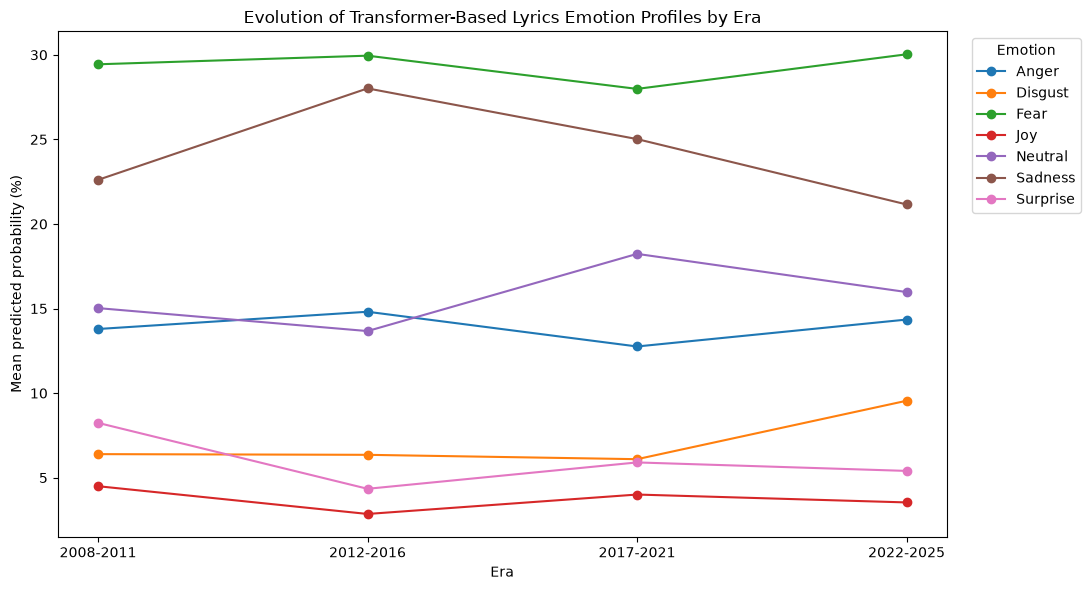

In [54]:
import matplotlib.pyplot as plt

# Cleaner emotion names for the legend
emotion_labels = {
    "transformer_anger": "Anger",
    "transformer_disgust": "Disgust",
    "transformer_fear": "Fear",
    "transformer_joy": "Joy",
    "transformer_neutral": "Neutral",
    "transformer_sadness": "Sadness",
    "transformer_surprise": "Surprise",
}

plot_data = transformer_by_era * 100

plt.figure(figsize=(11, 6))

for column in transformer_columns:
    plt.plot(
        plot_data.index,
        plot_data[column],
        marker="o",
        label=emotion_labels[column]
    )

plt.title("Evolution of Transformer-Based Lyrics Emotion Profiles by Era")
plt.xlabel("Era")
plt.ylabel("Mean predicted probability (%)")

plt.legend(
    title="Emotion",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

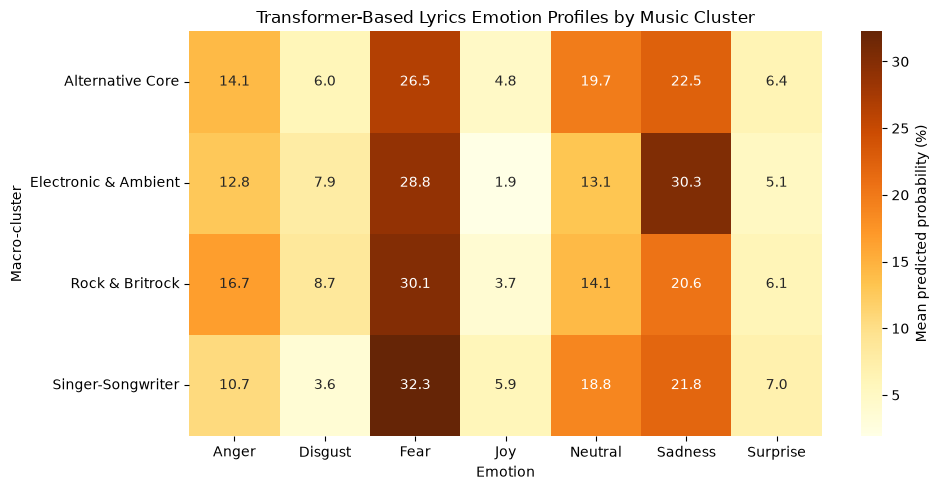

In [56]:
import seaborn as sns

# Convert probabilities to percentages
heatmap_data = transformer_by_macro * 100

# Clean column names
heatmap_data = heatmap_data.rename(
    columns=emotion_labels
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlOrBr",
    cbar_kws={
        "label": "Mean predicted probability (%)"
    }
)

plt.title("Transformer-Based Lyrics Emotion Profiles by Music Cluster")
plt.xlabel("Emotion")
plt.ylabel("Macro-cluster")

plt.tight_layout()
plt.show()

In [57]:
early = (
    transformer_by_era_macro
    .loc["2008-2011"]
)

late = (
    transformer_by_era_macro
    .loc["2022-2025"]
)

transformer_change = (late - early) * 100

# Clean emotion names
transformer_change = transformer_change.rename(
    columns=emotion_labels
)

transformer_change

,Anger,Disgust,Fear,Joy,Neutral,Sadness,Surprise
macro_cluster,,,,,,,
Alternative Core,5.577178,2.876447,1.304873,-0.174400,-1.238353,-5.899421,-2.446320
Electronic & Ambient,-2.008767,4.027904,1.128206,0.209123,-1.417494,1.662563,-3.601537
Rock & Britrock,-1.488146,2.126051,-6.131253,-2.078331,5.893843,2.619885,-0.942050
Singer-Songwriter,0.103040,1.235069,10.960607,1.437653,1.388768,-10.183498,-4.941641


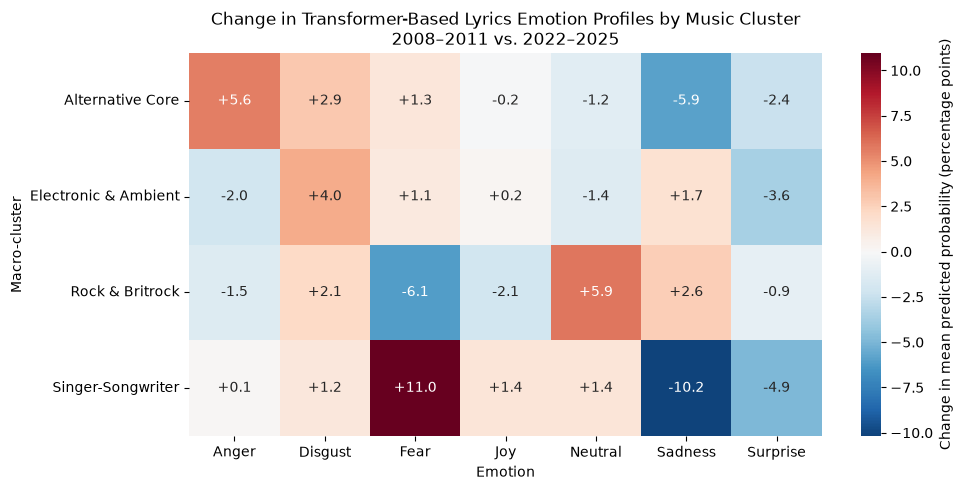

In [58]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    transformer_change,
    annot=True,
    fmt="+.1f",
    cmap="RdBu_r",
    center=0,
    cbar_kws={
        "label": "Change in mean predicted probability (percentage points)"
    }
)

plt.title(
    "Change in Transformer-Based Lyrics Emotion Profiles by Music Cluster\n"
    "2008–2011 vs. 2022–2025"
)

plt.xlabel("Emotion")
plt.ylabel("Macro-cluster")

plt.tight_layout()
plt.show()

## 8. Robustness and limitations

To assess whether the temporal patterns were driven by extreme model predictions, emotion profiles were recalculated using 5% trimmed means. All seven emotion dimensions preserved the direction of change between 2008–2011 and 2022–2025. Although the magnitude of some changes shifted slightly, the overall temporal pattern remained stable, suggesting that the observed trends are not primarily driven by extreme predictions.

In [59]:
# How confident is the model in its predictions? Let's look at the distribution of the maximum predicted probability for each track.

lyrics_df["transformer_confidence"] = (
    lyrics_df[transformer_columns].max(axis=1)
)

lyrics_df["transformer_confidence"].describe()

count    523.000000
mean       0.625002
std        0.214393
min        0.244427
25%        0.439854
50%        0.595293
75%        0.804218
max        0.992156
Name: transformer_confidence, dtype: float64

In [60]:
lyrics_df["transformer_confidence"].quantile(
    [0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
)

0.10    0.350688
0.25    0.439854
0.50    0.595293
0.75    0.804218
0.90    0.941612
0.95    0.971908
Name: transformer_confidence, dtype: float64

In [62]:
# trimmed mean

from scipy.stats import trim_mean

transformer_by_era_trimmed = (
    lyrics_df
    .groupby("era")[transformer_columns]
    .agg(lambda x: trim_mean(x, proportiontocut=0.05))
)

transformer_by_macro_trimmed = (
    lyrics_df
    .groupby("macro_cluster")[transformer_columns]
    .agg(lambda x: trim_mean(x, proportiontocut=0.05))
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [63]:
era_robustness_diff = (
    transformer_by_era_trimmed - transformer_by_era
) * 100

macro_robustness_diff = (
    transformer_by_macro_trimmed - transformer_by_macro
) * 100

era_robustness_diff.round(2)

,transformer_anger,transformer_disgust,transformer_fear,transformer_joy,transformer_neutral,transformer_sadness,transformer_surprise
era,,,,,,,
2008-2011,-2.53,-1.91,-1.91,-2.43,-1.54,-2.48,-2.97
2012-2016,-2.19,-1.65,-1.90,-1.53,-1.71,-1.98,-0.91
2017-2021,-2.12,-1.25,-2.05,-2.28,-1.95,-2.08,-1.09
2022-2025,-1.61,-2.12,-1.73,-2.25,-2.09,-2.47,-1.79


In [64]:
macro_robustness_diff.round(2)

,transformer_anger,transformer_disgust,transformer_fear,transformer_joy,transformer_neutral,transformer_sadness,transformer_surprise
macro_cluster,,,,,,,
Alternative Core,-1.71,-1.05,-2.29,-2.65,-2.10,-2.56,-1.74
Electronic & Ambient,-2.39,-2.26,-2.11,-0.79,-1.59,-1.82,-1.75
Rock & Britrock,-2.30,-2.08,-2.13,-2.40,-2.33,-2.73,-1.74
Singer-Songwriter,-2.66,-0.63,-1.71,-2.92,-1.30,-2.68,-2.19


In [ ]:
original_change = (
    transformer_by_era.loc["2022-2025"]
    - transformer_by_era.loc["2008-2011"]
) * 100

trimmed_change = (
    transformer_by_era_trimmed.loc["2022-2025"]
    - transformer_by_era_trimmed.loc["2008-2011"]
) * 100

robustness_comparison = pd.DataFrame({
    "original_change_pp": original_change,
    "trimmed_change_pp": trimmed_change
})

robustness_comparison["same_direction"] = (
    np.sign(robustness_comparison["original_change_pp"])
    ==
    np.sign(robustness_comparison["trimmed_change_pp"])
) # np.sign checks whether the values are positive, negative, or zero, allowing us to see if the direction of change is consistent between the original and trimmed means.

robustness_comparison.round(2)

,original_change_pp,trimmed_change_pp,same_direction
transformer_anger,0.56,1.48,True
transformer_disgust,3.16,2.95,True
transformer_fear,0.59,0.78,True
transformer_joy,-0.96,-0.78,True
transformer_neutral,0.95,0.40,True
transformer_sadness,-1.45,-1.44,True
transformer_surprise,-2.84,-1.66,True


The main temporal patterns remained directionally stable after trimming the most extreme model predictions, suggesting that the observed trends were not driven primarily by a small number of highly confident predictions.

## 9. NRC Lexicon vs. Transformer-Based Emotion Analysis

In [67]:
shared_emotions = [
    "anger",
    "disgust",
    "fear",
    "joy",
    "sadness",
    "surprise"
]

comparison_columns = []

for emotion in shared_emotions:
    comparison_columns.extend([
        f"{emotion}_share",
        f"transformer_{emotion}"
    ])
    
lyrics_df[comparison_columns].head()

,anger_share,transformer_anger,disgust_share,transformer_disgust,fear_share,transformer_fear,joy_share,transformer_joy,sadness_share,transformer_sadness,surprise_share,transformer_surprise
0,0.094340,0.359639,0.009434,0.021454,0.160377,0.127629,0.179245,0.283644,0.094340,0.026293,0.066038,0.015289
1,0.137931,0.196743,0.034483,0.046606,0.103448,0.040945,0.241379,0.023721,0.103448,0.020460,0.034483,0.021308
2,0.046875,0.046056,0.015625,0.014156,0.015625,0.098083,0.171875,0.033520,0.187500,0.613036,0.281250,0.008907
3,0.093750,0.201466,0.062500,0.032112,0.114583,0.363018,0.166667,0.020533,0.072917,0.117761,0.031250,0.048131
4,0.144928,0.031310,0.057971,0.006559,0.159420,0.034508,0.130435,0.002833,0.202899,0.892777,0.115942,0.020558


### 9.1 NRC-Transformer agreement

In [69]:
# Do lyrics associated more with e.g. sadness according to NRC get higher sadness correlation according to transformer?

emotion_correlations = {}

for emotion in shared_emotions:
    emotion_correlations[emotion] = lyrics_df[
        [f"{emotion}_share", f"transformer_{emotion}"]
    ].corr(method="spearman").iloc[0, 1]
    
emotion_correlations = (pd.Series(emotion_correlations, name="spearman_corr").sort_values(ascending=False))

emotion_correlations

joy         0.339365
disgust     0.190577
sadness     0.174293
anger       0.157623
fear        0.134463
surprise    0.062057
Name: spearman_corr, dtype: float64

Track-level agreement between the NRC lexicon scores and transformer probabilities was assessed using Spearman correlations for the six emotion categories shared by both methods. All correlations were positive, indicating broad directional agreement, but their magnitude was generally modest. Agreement was strongest for joy (ρ = 0.34), followed by disgust (ρ = 0.19), sadness (ρ = 0.17), anger (ρ = 0.16), and fear (ρ = 0.13). Surprise showed very little agreement (ρ = 0.06). These results suggest that the lexicon- and transformer-based approaches capture partially overlapping, but substantially different, aspects of emotional content.

### 9.1 NRC-Transformer temporal trend agreement

In [74]:
lyrics_df.columns

Index(['artist', 'track', 'artist_clean', 'track_clean', 'matched_artist',
       'matched_track', 'year_file', 'era', 'macro_cluster',
       'retrieval_status', 'plain_lyrics', 'synced_lyrics', 'lyrics_status',
       'lyrics_length', 'lyrics_clean', 'language', 'language_confidence',
       'total_tokens', 'matched_tokens', 'matched_categories',
       'lexicon_coverage', 'anger', 'anticipation', 'disgust', 'fear', 'joy',
       'negative', 'positive', 'sadness', 'surprise', 'trust', 'emotion_total',
       'anger_share', 'anticipation_share', 'disgust_share', 'fear_share',
       'joy_share', 'sadness_share', 'surprise_share', 'trust_share',
       'sentiment_total', 'positive_share', 'negative_share',
       'transformer_tokens', 'lyrics_chunks', 'n_chunks',
       'transformer_emotions', 'transformer_anger', 'transformer_disgust',
       'transformer_fear', 'transformer_joy', 'transformer_neutral',
       'transformer_sadness', 'transformer_surprise',
       'transformer_dominant

In [77]:
emotion_share_columns = [
    "anger_share",
    "anticipation_share",
    "disgust_share",
    "fear_share",
    "joy_share",
    "sadness_share",
    "surprise_share",
    "trust_share"
]

emotion_by_era = (
    lyrics_df
    .groupby("era")[emotion_share_columns]
    .mean()
)

In [78]:
lyrics_df[emotion_share_columns].isna().sum()

anger_share           9
anticipation_share    9
disgust_share         9
fear_share            9
joy_share             9
sadness_share         9
surprise_share        9
trust_share           9
dtype: int64

Transformer generated results for all 523 tracks, NRC for 514 (no metion in 9 tracks). We need to create a sample of the same 514 tracks for both methods

In [79]:
comparison_df = lyrics_df.dropna(
    subset=emotion_share_columns
).copy()

len(comparison_df)

514

In [80]:
comparison_df.groupby("era").size()

era
2008-2011    132
2012-2016    132
2017-2021    135
2022-2025    115
dtype: int64

In [81]:
nrc_by_era_comparison = (
    comparison_df
    .groupby("era")[emotion_share_columns]
    .mean()
)

transformer_by_era_comparison = (
    comparison_df
    .groupby("era")[transformer_columns]
    .mean()
)

In [82]:
nrc_change = (
    nrc_by_era_comparison.loc["2022-2025"]
    - nrc_by_era_comparison.loc["2008-2011"]
) * 100

transformer_change = (
    transformer_by_era_comparison.loc["2022-2025"]
    - transformer_by_era_comparison.loc["2008-2011"]
) * 100

In [83]:
temporal_comparison = pd.DataFrame({
    "nrc_change_pp": [
        nrc_change[f"{emotion}_share"]
        for emotion in shared_emotions
    ],
    "transformer_change_pp": [
        transformer_change[f"transformer_{emotion}"]
        for emotion in shared_emotions
    ]
}, index=shared_emotions)

temporal_comparison["same_direction"] = (
    np.sign(temporal_comparison["nrc_change_pp"])
    ==
    np.sign(temporal_comparison["transformer_change_pp"])
)

temporal_comparison.round(2)

,nrc_change_pp,transformer_change_pp,same_direction
anger,0.33,0.58,True
disgust,0.98,3.20,True
fear,-1.06,0.45,False
joy,-0.03,-0.95,True
sadness,0.61,-0.74,False
surprise,-1.57,-3.26,True


Temporal changes between 2008–2011 and 2022–2025 were compared on the same subset of 514 tracks for which both NRC and transformer-based emotion profiles were available. Four of the six shared emotion categories showed the same direction of change across methods: anger and disgust increased, while joy and surprise decreased. However, the NRC change in joy was close to zero (−0.03 percentage points), so this directional agreement should be interpreted cautiously.

Fear and sadness showed opposite temporal patterns across methods. NRC indicated a decrease in fear and an increase in sadness, whereas the transformer indicated a slight increase in fear and a decrease in sadness. Together with the modest track-level correlations, these differences suggest that the two approaches capture related but non-equivalent aspects of emotional content.

### 9.2 NRC-Transformer macro-cluster trend agreement

In [84]:
nrc_by_macro_comparison = (
    comparison_df
    .groupby("macro_cluster")[emotion_share_columns]
    .mean()
)

transformer_by_macro_comparison = (
    comparison_df
    .groupby("macro_cluster")[transformer_columns]
    .mean()
)

In [85]:
# preparation of comparable profiles (absolute values of NRC and transformer are not comparable)

nrc_shared = nrc_by_macro_comparison[
    [f"{emotion}_share" for emotion in shared_emotions]
].copy()

nrc_shared.columns = shared_emotions

transformer_shared = transformer_by_macro_comparison[
    [f"transformer_{emotion}" for emotion in shared_emotions]
].copy()

transformer_shared.columns = shared_emotions

In [86]:
nrc_shared_norm = nrc_shared.div(
    nrc_shared.sum(axis=1),
    axis=0
)

transformer_shared_norm = transformer_shared.div(
    transformer_shared.sum(axis=1),
    axis=0
)

In [87]:
nrc_shared_norm.sum(axis=1)

macro_cluster
Alternative Core        1.0
Electronic & Ambient    1.0
Rock & Britrock         1.0
Singer-Songwriter       1.0
dtype: float64

In [88]:
transformer_shared_norm.sum(axis=1)

macro_cluster
Alternative Core        1.0
Electronic & Ambient    1.0
Rock & Britrock         1.0
Singer-Songwriter       1.0
dtype: float64

In [89]:
# Do NRC and transformer similarly rank emotions when creating macro-cluster profiles?

macro_profile_agreement = {}

for cluster in nrc_shared_norm.index:
    macro_profile_agreement[cluster] = (
        nrc_shared_norm.loc[cluster]
        .corr(
            transformer_shared_norm.loc[cluster],
            method="spearman"
        )
    )

macro_profile_agreement = pd.Series(
    macro_profile_agreement,
    name="spearman_corr"
)

macro_profile_agreement

Alternative Core       -0.028571
Electronic & Ambient    0.085714
Rock & Britrock         0.085714
Singer-Songwriter       0.371429
Name: spearman_corr, dtype: float64

In [90]:
macro_dominant_comparison = pd.DataFrame({
    "nrc_dominant": nrc_shared_norm.idxmax(axis=1),
    "transformer_dominant": transformer_shared_norm.idxmax(axis=1)
})

macro_dominant_comparison["same_dominant"] = (
    macro_dominant_comparison["nrc_dominant"]
    ==
    macro_dominant_comparison["transformer_dominant"]
)

macro_dominant_comparison

,nrc_dominant,transformer_dominant,same_dominant
macro_cluster,,,
Alternative Core,joy,fear,False
Electronic & Ambient,joy,sadness,False
Rock & Britrock,joy,fear,False
Singer-Songwriter,joy,fear,False


Disparity between lexical emotion associations and contextual emotion classifications. The two approaches show partial agreement in temporal trends, but weak agreement in absolute emotion profiles. Lexicon-based associations and contextual transformer predictions therefore appear to capture complementary dimensions of emotional content in lyrics.

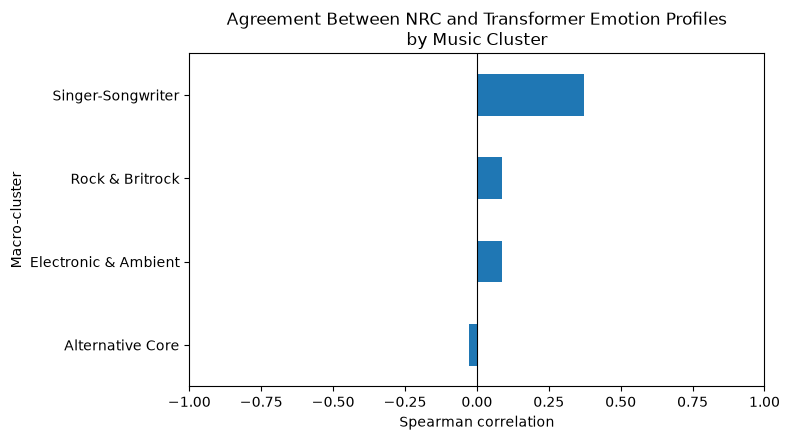

In [91]:
# NRC vs Transformer profile correlation per macro-cluster

plt.figure(figsize=(8, 4.5))

macro_profile_agreement.sort_values().plot(
    kind="barh"
)

plt.axvline(0, color="black", linewidth=0.8)

plt.xlabel("Spearman correlation")
plt.ylabel("Macro-cluster")
plt.title(
    "Agreement Between NRC and Transformer Emotion Profiles\n"
    "by Music Cluster"
)

plt.xlim(-1, 1)

plt.tight_layout()
plt.show()

### NRC vs. Transformer Emotion Profiles

Agreement between NRC-based and transformer-based emotion profiles is generally low
across music clusters. Spearman correlations are close to zero for Alternative Core,
Electronic & Ambient, and Rock & Britrock, indicating that the two approaches produce
substantially different rankings of emotions within these clusters.

Singer-Songwriter shows the highest agreement, although the correlation remains
moderate.

This divergence is consistent with the methodological differences between the two
approaches. NRC measures lexical emotion associations based on individual words,
whereas the transformer model estimates emotions from contextualized text segments.
The two methods therefore appear to capture complementary rather than interchangeable
aspects of emotional content in lyrics.

In [93]:
columns_to_drop = [
    "lyrics_chunks",
    "transformer_emotions"
]

final_df = lyrics_df.drop(
    columns=columns_to_drop,
    errors="ignore"
)

OUTPUT_PATH = "../data/processed/lyrics_with_transformer_emotions.csv"

final_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Shape:", final_df.shape)
print("Saved to:", OUTPUT_PATH)

Shape: (523, 54)
Saved to: ../data/processed/lyrics_with_transformer_emotions.csv


In [94]:
check_df = pd.read_csv(OUTPUT_PATH)

print("Shape:", check_df.shape)

check_df[
    [
        "artist",
        "track",
        "era",
        "macro_cluster",
        "transformer_dominant_emotion"
    ]
].head()

Shape: (523, 54)


,artist,track,era,macro_cluster,transformer_dominant_emotion
0,Angels & Airwaves,Secret Crowds,2008-2011,Alternative Core,anger
1,Red Hot Chili Peppers,Monarchy of Roses,2008-2011,Alternative Core,neutral
2,Brandon Flowers,Only the Young,2008-2011,Alternative Core,sadness
3,Pennywise,Living for Today,2008-2011,Alternative Core,fear
4,Katie Melua,The Closest Thing to Crazy,2008-2011,Alternative Core,sadness


## Conclusions

The transformer-based analysis provides a contextual perspective on the emotional
content of the lyrics and reveals a substantially different overall profile from the
lexicon-based NRC analysis.

Across the full dataset, fear and sadness receive the highest mean predicted
probabilities, while joy is comparatively low. Emotional profiles also differ across
music clusters: Electronic & Ambient is characterized by relatively high sadness,
Singer-Songwriter by high fear, and Rock & Britrock by relatively high anger.

Temporal changes are not consistent with a simple shift toward either more positive
or more negative lyrics. Instead, individual emotions follow distinct trajectories.
The most recent era (2022–2025), for example, combines relatively high fear and
disgust with lower sadness than earlier periods. Cluster-level analysis further shows
that these changes are heterogeneous: different music clusters follow substantially
different emotional trajectories over time.

The robustness analysis preserved the direction of the observed era-level changes
across all seven transformer emotion categories, suggesting that the main temporal
patterns are not driven solely by extreme observations.

### Comparison with the NRC Lexicon Analysis

The NRC lexicon and transformer model show limited agreement in their absolute
emotion profiles. NRC-based profiles are dominated by joy across all four music
clusters, whereas the transformer identifies fear as dominant in Alternative Core,
Rock & Britrock, and Singer-Songwriter, and sadness in Electronic & Ambient.
Correlations between the two emotion profiles are generally weak.

At the same time, several temporal directions are consistent across methods,
including changes in anger, disgust, joy, and surprise. This suggests that the two
approaches capture partly complementary aspects of emotional language rather than
providing interchangeable measurements.

Because the transformer incorporates contextual information, its results are treated
as the primary contextual analysis in this project, while the NRC analysis provides
a transparent lexical perspective. Neither approach should be interpreted as ground
truth: the transformer is also dependent on its training data, emotion taxonomy, and
the suitability of its learned representations for song lyrics. Song lyrics are very specific type
of text, highly metaphorical, with considerable amount of repetitions.

Overall, the results suggest that the emotional landscape of the lyrics is better
described as multidimensional and genre-dependent than as a simple change in
positive versus negative sentiment.